# 04 — Analysis of the S8 scoring run

**Preliminary findings for Meeting 2 — for discussion, not citation.**

Run `20261003T110419Z`: 5,200 floor speeches, 100 per Congress × party × chamber
(107th–119th Congress, 2001–2025), scored for ideology (−1 liberal … +1
conservative) and tone (0 neutral … 1 hostile) by DeepSeek-V4.1-Flash and GPT-4o;
the ensemble score is their mean. How the run was made and why:
`docs/decisions.md` S8, S11, S13–S16, M3b.

Rules throughout:

- **House and Senate are never pooled.** The govinfo Senate is thinner than
  Stanford's (O8), and every cell has the same quota, so a pooled mean would not be
  a corpus mean (S11).
- **Every interval is clustered by member** (career-long ICPSR). Many speeches come
  from the same member; treating them as independent would overstate the evidence.
- **The 2016-09-10 source break** (Stanford → govinfo) is marked in every time series
  as a dashed line at the 114th Congress, which holds both sources.

The logic lives in `code/src/analysis.py` and `code/src/plots.py` (tested); this
notebook only calls it. Figures are saved to `results/plots/`. No API calls.

In [1]:
import json
import sys
import textwrap
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "CLAUDE.md").exists())
sys.path.insert(0, str(ROOT / "code"))

import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

from src.analysis import (
    cell_means, disagreements, load_scored_run, member_means, party_gap,
    speech_texts, trend,
)
from src.config import METRICS_DIR, SCORES_DIR, SOURCE_BREAK_CONGRESS
from src.plots import (
    plot_gap, plot_member_validation, plot_models, plot_party_positions, save_figure,
)
from src.runs import run_models

%matplotlib inline
pd.set_option("display.precision", 3)
pd.set_option("display.max_colwidth", 80)

RUN = "20261003T110419Z"        # the S8 run
PILOT_RUN = "20261003T100851Z"  # the three-model stage-1 pilot (P6)

df = load_scored_run(RUN)
MODELS = run_models(SCORES_DIR, RUN)
print(f"{len(df):,} speeches, models: {', '.join(MODELS)}")

5,200 speeches, models: deepseek-flash, gpt-4o-2024-11-20


In [2]:
def with_ci(table, value="mean", digits=2):
    """'0.46 [0.35, 0.57]' -- a value with its 95% interval."""
    return table.apply(
        lambda r: f"{r[value]:+.{digits}f} [{r['ci_low']:+.{digits}f}, {r['ci_high']:+.{digits}f}]",
        axis=1,
    )

## 1. What was scored

The design, the two models and what the run cost. Procedural speeches — the
models put exactly 0.0 on both scores, as the prompt instructs for speech with
no ideological content — stay in every figure; they pull means toward zero
equally for both parties.

In [3]:
summary = json.loads((METRICS_DIR / f"s8_summary_{RUN}.json").read_text())
pd.DataFrame({
    model: {
        "answered by": ", ".join(s["served_models"]),
        "calls": s["calls"],
        "speeches without a score": s["failures"],
        "cost, USD (list prices)": round(s["cost_usd"], 2),
    }
    for model, s in summary["per_model"].items()
}).T

,answered by,calls,speeches without a score,"cost, USD (list prices)"
deepseek-flash,deepseek-flash,5202,0,4.9
gpt-4o-2024-11-20,gpt-4o-2024-11-20,5200,0,16.19


In [4]:
print("Speeches per Congress x chamber x party:")
df.groupby(["congress_number", "chamber", "party"]).size().unstack(["chamber", "party"]).T

Speeches per Congress x chamber x party:


congress_number  107  108  109  110  111  112  113  114  115  116  117  118  \
chamber party                                                                 
H       D        100  100  100  100  100  100  100  100  100  100  100  100   
        R        100  100  100  100  100  100  100  100  100  100  100  100   
S       D        100  100  100  100  100  100  100  100  100  100  100  100   
        R        100  100  100  100  100  100  100  100  100  100  100  100   

congress_number  119  
chamber party         
H       D        100  
        R        100  
S       D        100  
        R        100

In [5]:
print("Source of the sampled speeches per Congress (the 114th holds both):")
pd.crosstab(df["congress_number"], df["source"]).T

Source of the sampled speeches per Congress (the 114th holds both):


congress_number,107,108,109,110,111,112,113,114,115,116,117,118,119
source,,,,,,,,,,,,,
govinfo,0,0,0,0,0,0,0,38,400,400,400,400,400
stanford,400,400,400,400,400,400,400,362,0,0,0,0,0


In [6]:
pd.DataFrame({
    "procedural share": pd.concat([
        df.groupby("chamber")["procedural"].mean(),
        df.groupby("source")["procedural"].mean(),
        df.groupby("party")["procedural"].mean(),
    ]),
}).round(3)

,procedural share
H,0.262
S,0.353
govinfo,0.293
stanford,0.317
D,0.277
R,0.338


**Reading it.** All 5,200 speeches carry both models' scores. About 30% are procedural. The share is similar in both sources (29% govinfo, 32% Stanford) but higher in the Senate (35% vs 26% in the House) and for Republicans (34% vs 28%). Procedural speeches sit at 0.0 and pull a party's mean toward the centre, so a party with more of them looks more moderate — worth a robustness check without them.

## 2. RQ1 — How far apart are the parties?

The gap is the Republican mean minus the Democratic mean, per Congress and
chamber. A wider gap means more polarized floor rhetoric.

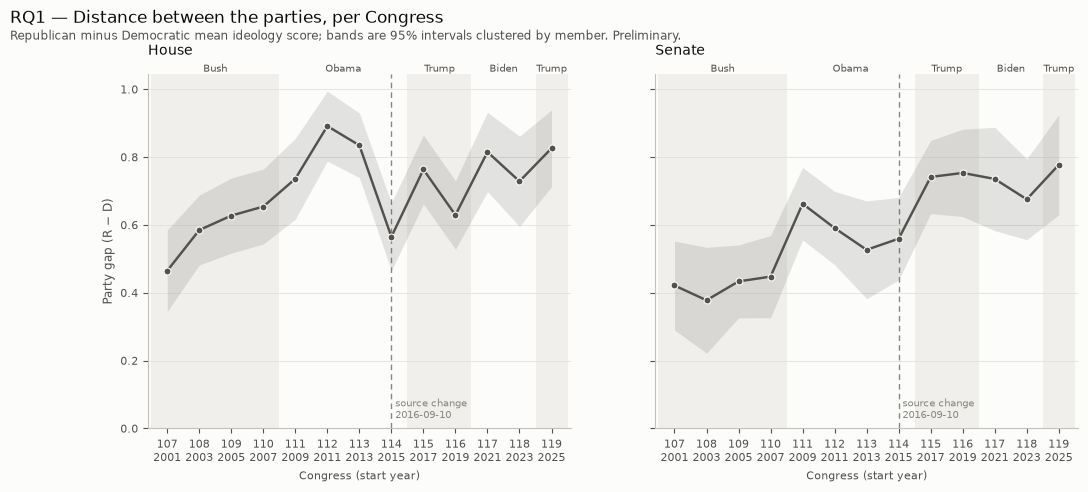

chamber,H,S
congress_number,,
107,"+0.46 [+0.34, +0.58]","+0.42 [+0.29, +0.55]"
108,"+0.58 [+0.48, +0.69]","+0.38 [+0.22, +0.53]"
109,"+0.63 [+0.52, +0.74]","+0.43 [+0.33, +0.54]"
110,"+0.65 [+0.54, +0.76]","+0.45 [+0.33, +0.57]"
111,"+0.74 [+0.62, +0.86]","+0.66 [+0.56, +0.77]"
112,"+0.89 [+0.79, +0.99]","+0.59 [+0.48, +0.70]"
113,"+0.83 [+0.74, +0.93]","+0.53 [+0.38, +0.67]"
114,"+0.56 [+0.47, +0.66]","+0.56 [+0.44, +0.68]"
115,"+0.76 [+0.66, +0.86]","+0.74 [+0.63, +0.85]"


In [7]:
cells = cell_means(df)
gaps = party_gap(cells)
fig = plot_gap(
    gaps,
    "RQ1 — Distance between the parties, per Congress",
    subtitle="Republican minus Democratic mean ideology score; bands are 95% intervals clustered by member. Preliminary.",
)
save_figure(fig, "s8_party_gap")
plt.show()

gaps.assign(gap_ci=with_ci(gaps, "gap")).pivot(index="congress_number", columns="chamber", values="gap_ci")

**Reading it.** The gap widened in both chambers: the House from 0.46 [0.34, 0.58] in the 107th Congress to 0.83 [0.71, 0.94] in the 119th, the Senate from 0.42 [0.29, 0.55] to 0.78 [0.63, 0.92]. In the House most of the rise came before the source change (0.89 already in the 112th). The Senate rose in two steps, at the 111th and at the 115th; the second coincides with the source change (section 4 and the caveats). The House dips in the 114th (0.56), in both parties at once.

## 3. RQ2 — Which party moved?

Each party's own position, per Congress — the plot Yufei asked for in Meeting 1.
A widening gap could come from one party moving, or both.

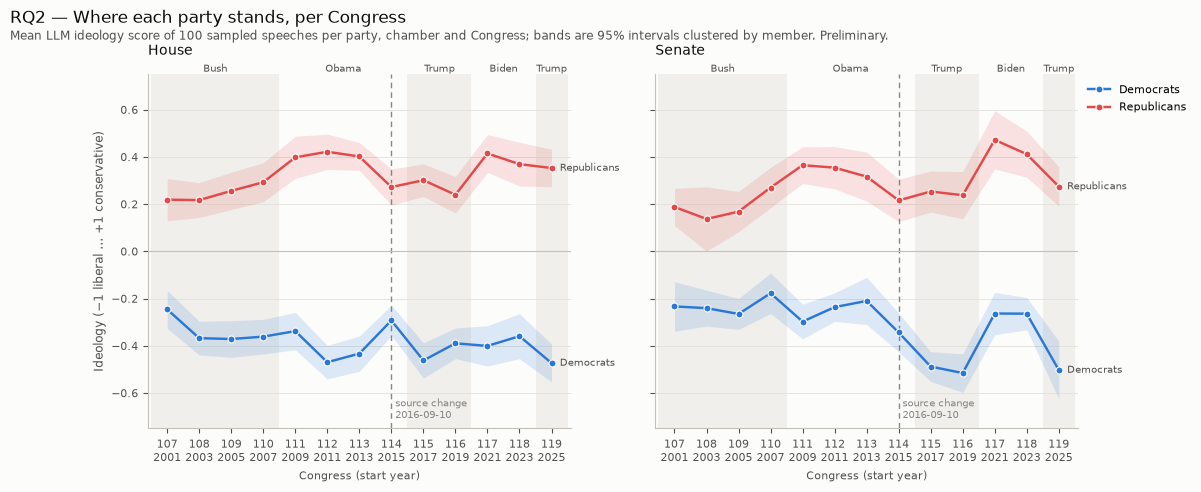

In [8]:
fig = plot_party_positions(
    cells,
    "Ideology (−1 liberal … +1 conservative)",
    "RQ2 — Where each party stands, per Congress",
    subtitle="Mean LLM ideology score of 100 sampled speeches per party, chamber and Congress; bands are 95% intervals clustered by member. Preliminary.",
    ylim=(-0.75, 0.75),
)
save_figure(fig, "s8_party_positions")
plt.show()

**Trend per party.** A straight-line summary of each party's movement: the slope
per Congress and the fitted change over the window. Two windows: 2001–2016 has a
single source (Stanford), so no source change can drive it; the full window
includes the 2016 break.

In [9]:
trends = pd.concat([
    trend(df, congress_range=(107, 114)).assign(window="2001–2016, Stanford only"),
    trend(df).assign(window="2001–2025, both sources"),
])
trends.assign(
    slope_ci=with_ci(trends, "slope", digits=3),
    change=trends["change_over_span"].round(2),
    p=trends["p"].map(lambda p: f"{p:.2g}"),
)[["window", "chamber", "party", "span", "slope_ci", "change", "p", "n_members"]].reset_index(drop=True)

,window,chamber,party,span,slope_ci,change,p,n_members
0,"2001–2016, Stanford only",H,D,107-114,"-0.011 [-0.023, +0.001]",-0.08,0.083,271
1,"2001–2016, Stanford only",H,R,107-114,"+0.023 [+0.011, +0.035]",0.16,0.00025,308
2,"2001–2016, Stanford only",S,D,107-114,"-0.008 [-0.020, +0.004]",-0.05,0.21,88
3,"2001–2016, Stanford only",S,R,107-114,"+0.021 [+0.003, +0.039]",0.15,0.025,93
4,"2001–2025, both sources",H,D,107-119,"-0.009 [-0.016, -0.002]",-0.11,0.015,377
5,"2001–2025, both sources",H,R,107-119,"+0.009 [+0.002, +0.016]",0.11,0.01,446
6,"2001–2025, both sources",S,D,107-119,"-0.018 [-0.027, -0.009]",-0.21,0.00011,106
7,"2001–2025, both sources",S,R,107-119,"+0.015 [+0.006, +0.023]",0.17,0.0013,117


**Reading it.** In the single-source window (2001–2016), **Republicans moved right in both chambers**: +0.16 in the House (p < 0.001) and +0.15 in the Senate (p = 0.03). Democrats moved slightly left, but not clearly: −0.08 in the House (p = 0.08), −0.05 in the Senate (p = 0.21). Over the full window both parties move outward; the largest Democratic move is in the Senate (−0.21), concentrated after 2016, where the source changes. The plot also shows each party's position rising and falling with presidential terms (section 7), so a straight line is only a summary.

## 4. Does the 2016 source change shift the scores?

The 114th Congress is the only one with speeches from both sources, so it allows
a comparison within one Congress. govinfo covers only its last four months, so
few sampled speeches come from it.

In [10]:
mixed = df[df["congress_number"] == SOURCE_BREAK_CONGRESS]
by_source = cell_means(mixed, by=("chamber", "party", "source"))
by_source.assign(mean_ci=with_ci(by_source))[["chamber", "party", "source", "n", "n_members", "mean_ci"]]

,chamber,party,source,n,n_members,mean_ci
0,H,D,govinfo,6,6,"-0.38 [-0.76, -0.01]"
1,H,D,stanford,94,67,"-0.29 [-0.35, -0.22]"
2,H,R,govinfo,13,10,"+0.17 [+0.01, +0.32]"
3,H,R,stanford,87,66,"+0.29 [+0.21, +0.37]"
4,S,D,govinfo,12,9,"-0.57 [-0.70, -0.44]"
5,S,D,stanford,88,37,"-0.31 [-0.41, -0.22]"
6,S,R,govinfo,7,6,"-0.07 [-0.14, +0.01]"
7,S,R,stanford,93,38,"+0.24 [+0.15, +0.33]"


**Reading it.** Too few govinfo speeches fall in the 114th (6–13 per party and chamber, all from its last four months) to separate the source from the moment — the 2016 election and the lame-duck session. And the differences do not point one way: govinfo Democrats sit further left, govinfo Republicans closer to the centre than their Stanford counterparts. So there is no sign of a uniform shift toward the extremes in govinfo, but no proof of its absence either.

## 5. Validation against DW-NOMINATE

DW-NOMINATE places members by their roll-call votes; the LLM scores place their
speeches. Votes and rhetoric are different signals, so the correlation should be
positive and meaningful, not perfect (CLAUDE.md, M5).

Across both parties, any measure that separates the parties correlates highly —
that mostly re-measures the party split (P5). **The within-party rows are the real
test**: do the scores order members inside a party the way their votes do?

In [11]:
val = json.loads((METRICS_DIR / f"validation_{RUN}.json").read_text())
rows = []
for subset, benchmarks in val["results"].items():
    for benchmark, columns in benchmarks.items():
        for column, groups in columns.items():
            rows.append({
                "speeches": subset, "benchmark": benchmark, "score": column,
                **{
                    group: f"{g['pearson_r']:+.2f} [{g['pearson_ci95'][0]:+.2f}, {g['pearson_ci95'][1]:+.2f}]"
                    for group, g in groups.items()
                },
            })
pd.DataFrame(rows).rename(columns={"all": "both parties", "D": "within D", "R": "within R"})

,speeches,benchmark,score,both parties,within D,within R
0,all_speeches,nominate_dim1,ensemble,"+0.69 [+0.68, +0.71]","+0.25 [+0.22, +0.29]","+0.33 [+0.29, +0.36]"
1,all_speeches,nominate_dim1,deepseek-flash,"+0.66 [+0.65, +0.68]","+0.24 [+0.21, +0.28]","+0.32 [+0.28, +0.35]"
2,all_speeches,nominate_dim1,gpt-4o-2024-11-20,"+0.70 [+0.69, +0.72]","+0.25 [+0.21, +0.28]","+0.33 [+0.29, +0.36]"
3,all_speeches,nokken_poole_dim1,ensemble,"+0.69 [+0.68, +0.71]","+0.25 [+0.22, +0.29]","+0.32 [+0.29, +0.36]"
4,all_speeches,nokken_poole_dim1,deepseek-flash,"+0.66 [+0.65, +0.68]","+0.24 [+0.21, +0.28]","+0.31 [+0.28, +0.35]"
5,all_speeches,nokken_poole_dim1,gpt-4o-2024-11-20,"+0.70 [+0.69, +0.72]","+0.25 [+0.21, +0.28]","+0.32 [+0.28, +0.35]"
6,non_procedural,nominate_dim1,ensemble,"+0.81 [+0.80, +0.82]","+0.25 [+0.20, +0.29]","+0.35 [+0.31, +0.39]"
7,non_procedural,nominate_dim1,deepseek-flash,"+0.77 [+0.76, +0.78]","+0.23 [+0.19, +0.27]","+0.33 [+0.29, +0.37]"
8,non_procedural,nominate_dim1,gpt-4o-2024-11-20,"+0.82 [+0.81, +0.83]","+0.24 [+0.20, +0.28]","+0.35 [+0.30, +0.39]"
9,non_procedural,nokken_poole_dim1,ensemble,"+0.81 [+0.79, +0.82]","+0.25 [+0.21, +0.29]","+0.34 [+0.30, +0.38]"


**Member level (exploratory, O9).** A single speech is a noisy reading of a
member. Averaging each member's speeches — members with at least five in the
sample — gives a cleaner comparison. Which unit the thesis uses is still open (O9).

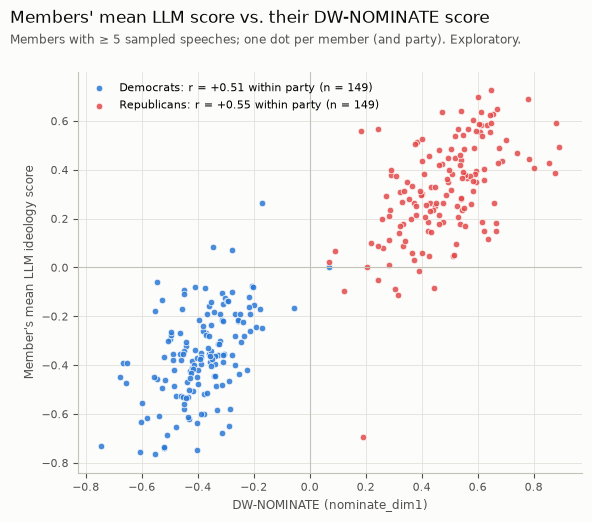

,nominate_dim1,nokken_poole_dim1
D,0.51,0.50
R,0.55,0.56
n members,298.00,298.00


In [12]:
members = member_means(df, min_speeches=5)
fig = plot_member_validation(
    members,
    title="Members' mean LLM score vs. their DW-NOMINATE score",
    subtitle="Members with ≥ 5 sampled speeches; one dot per member (and party). Exploratory.",
)
save_figure(fig, "s8_member_validation")
plt.show()

pd.DataFrame({
    benchmark: {
        party: round(m["ideology"].corr(m[benchmark]), 2)
        for party, m in members.groupby("party")
    } | {"n members": len(members)}
    for benchmark in ("nominate_dim1", "nokken_poole_dim1")
})

**Reading it.** At speech level the scores correlate with DW-NOMINATE at r ≈ 0.69 across parties (0.81 without procedural speeches) and **0.25 within Democrats and 0.33 within Republicans**, with tight intervals; both models and both benchmarks give the same picture. Averaging per member makes the within-party agreement much stronger: **r = 0.51 (D) and 0.55 (R)** for the 298 members with at least five sampled speeches. That fits P5: a single speech is a noisy measurement of a member, and the signal is there once a member's speeches are averaged. Caveat: frequent speakers are not a random set of members.

## 6. RQ5 — Has the tone become more hostile?

Tone is scored separately from ideology: how charged or hostile the language is,
whatever its position.

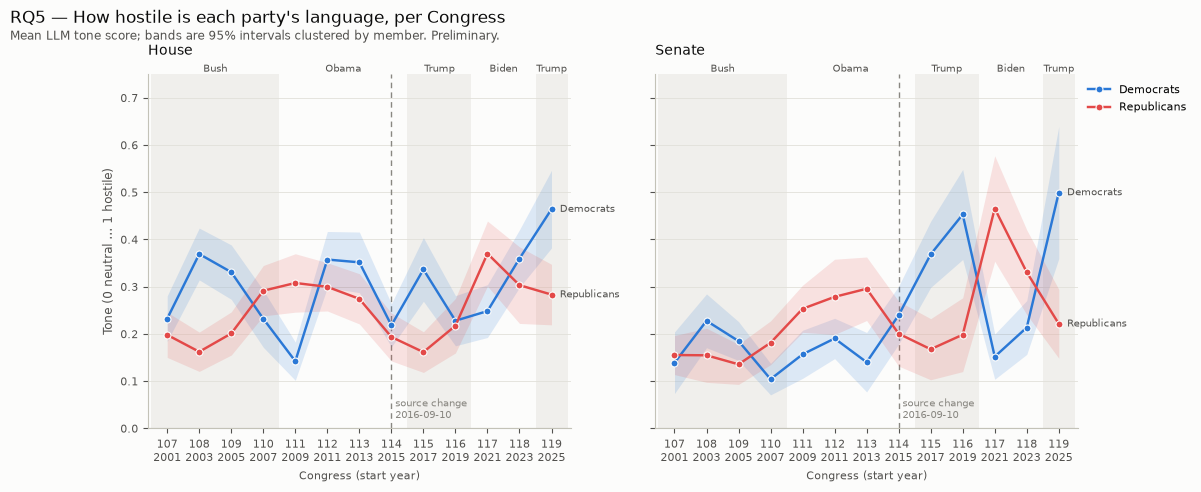

In [13]:
tone_cells = cell_means(df, value="tone")
fig = plot_party_positions(
    tone_cells,
    "Tone (0 neutral … 1 hostile)",
    "RQ5 — How hostile is each party's language, per Congress",
    subtitle="Mean LLM tone score; bands are 95% intervals clustered by member. Preliminary.",
    ylim=(0, 0.75),
)
save_figure(fig, "s8_tone_positions")
plt.show()

**Is the party out of the White House harsher?** Tone by whether the speaker's
party held the presidency during that Congress.

In [14]:
opposition = cell_means(df, value="tone", by=("chamber", "party", "in_opposition"))
opposition.assign(
    role=opposition["in_opposition"].map({True: "in opposition", False: "holds the presidency"}),
    tone=with_ci(opposition),
).pivot(index=["chamber", "party"], columns="role", values="tone")

role           holds the presidency         in opposition
chamber party                                            
H       D      +0.28 [+0.25, +0.31]  +0.31 [+0.28, +0.34]
        R      +0.22 [+0.20, +0.24]  +0.29 [+0.26, +0.32]
S       D      +0.18 [+0.16, +0.21]  +0.28 [+0.22, +0.35]
        R      +0.17 [+0.15, +0.20]  +0.30 [+0.25, +0.36]

**Does tone track ideology?** Speech-level Spearman correlation between tone and
how far a speech sits from the centre (|ideology|), within each party,
procedural speeches excluded. Descriptive only.

In [15]:
substantive = df[~df["procedural"]]
pd.DataFrame({
    party: {
        "rho": round(stats.spearmanr(d["tone"], d["ideology"].abs()).statistic, 2),
        "n": len(d),
    }
    for party, d in substantive.groupby("party")
}).T

,rho,n
D,0.59,1881.0
R,0.70,1720.0


**Reading it.** The party out of the White House is clearly harsher in the Senate (Democrats 0.28 vs 0.18, Republicans 0.30 vs 0.17) and among House Republicans (0.29 vs 0.22); for House Democrats the difference is small (0.31 vs 0.28). The steepest rise is in 2025 (119th Congress), for Democrats in both chambers. Tone and ideological extremity go together at speech level (Spearman 0.59 for Democrats, 0.70 for Republicans) — but both are scored by the same models from the same text, so part of that may be the models conflating "strongly partisan" with "hostile". That needs checking before RQ5 can claim tone moves with ideology.

## 7. RQ3 — Does the picture differ by presidential term?

Each party's mean ideology and tone per presidential term and chamber. Terms are
assigned per Congress (each Congress to the president who held office for nearly
all of it).

In [16]:
term_order = list(dict.fromkeys(df.sort_values("congress_number")["term"]))

def by_term(value):
    t = cell_means(df, value=value, by=("term", "chamber", "party"))
    t["cell"] = t["chamber"] + " · " + t["party"]
    return (
        t.assign(v=t.apply(lambda r: f"{r['mean']:+.2f} ±{r['se']:.2f}", axis=1))
        .pivot(index="term", columns="cell", values="v")
        .loc[term_order]
    )

print("Ideology (mean ± clustered SE)")
display(by_term("ideology"))
print("Tone (mean ± clustered SE)")
display(by_term("tone"))

Ideology (mean ± clustered SE)


cell,H · D,H · R,S · D,S · R
term,,,,
Bush 2001-2008,-0.34 ±0.02,+0.25 ±0.02,-0.23 ±0.03,+0.19 ±0.04
Obama 2009-2016,-0.38 ±0.02,+0.37 ±0.02,-0.27 ±0.03,+0.31 ±0.03
Trump 2017-2020,-0.43 ±0.03,+0.27 ±0.03,-0.50 ±0.03,+0.25 ±0.04
Biden 2021-2024,-0.38 ±0.03,+0.39 ±0.03,-0.26 ±0.03,+0.44 ±0.05
Trump 2025-2026,-0.47 ±0.04,+0.35 ±0.04,-0.50 ±0.06,+0.27 ±0.04


Tone (mean ± clustered SE)


cell,H · D,H · R,S · D,S · R
term,,,,
Bush 2001-2008,+0.29 ±0.02,+0.21 ±0.01,+0.16 ±0.02,+0.16 ±0.01
Obama 2009-2016,+0.27 ±0.02,+0.27 ±0.01,+0.18 ±0.02,+0.26 ±0.02
Trump 2017-2020,+0.28 ±0.02,+0.19 ±0.02,+0.41 ±0.03,+0.18 ±0.03
Biden 2021-2024,+0.30 ±0.02,+0.34 ±0.03,+0.18 ±0.02,+0.40 ±0.04
Trump 2025-2026,+0.46 ±0.04,+0.28 ±0.03,+0.50 ±0.07,+0.22 ±0.04


**Reading it.** Both scores follow the presidency: each party's rhetoric is more extreme when it is in opposition. Senate Republicans are furthest right under Obama and Biden (+0.31 and +0.44, against +0.19 and +0.25 under Bush and Trump's first term); Senate Democrats are furthest left under Trump (−0.50 in both terms, against −0.23 to −0.27 otherwise). That matters for RQ2: part of "who moved" is who was in opposition when. A long-run trend and this opposition cycle overlap, and 13 Congresses are few to separate them.

## 8. Model comparison

The run uses two models; Claude Sonnet 4.6 was dropped because it agreed with
GPT-4o almost perfectly in the pilots and cost the most (S15). This section shows
how far the two remaining models agree, and whether each tells the same story on
its own.

In [17]:
a, b = (f"ideology_{m}" for m in MODELS)
agreement = {
    "Pearson r": {g: round(d[a].corr(d[b]), 3) for g, d in [("all", df), *df.groupby("party")]},
    f"mean {MODELS[0]} − {MODELS[1]}": {
        g: round((d[a] - d[b]).mean(), 3) for g, d in [("all", df), *df.groupby("party")]
    },
    "share differing by > 0.42": {
        g: round(((d[a] - d[b]).abs() > 0.42).mean(), 3) for g, d in [("all", df), *df.groupby("party")]
    },
}
pd.DataFrame(agreement).T

,all,D,R
Pearson r,0.940,0.884,0.914
mean deepseek-flash − gpt-4o-2024-11-20,0.007,0.041,-0.027
share differing by > 0.42,0.043,0.046,0.040


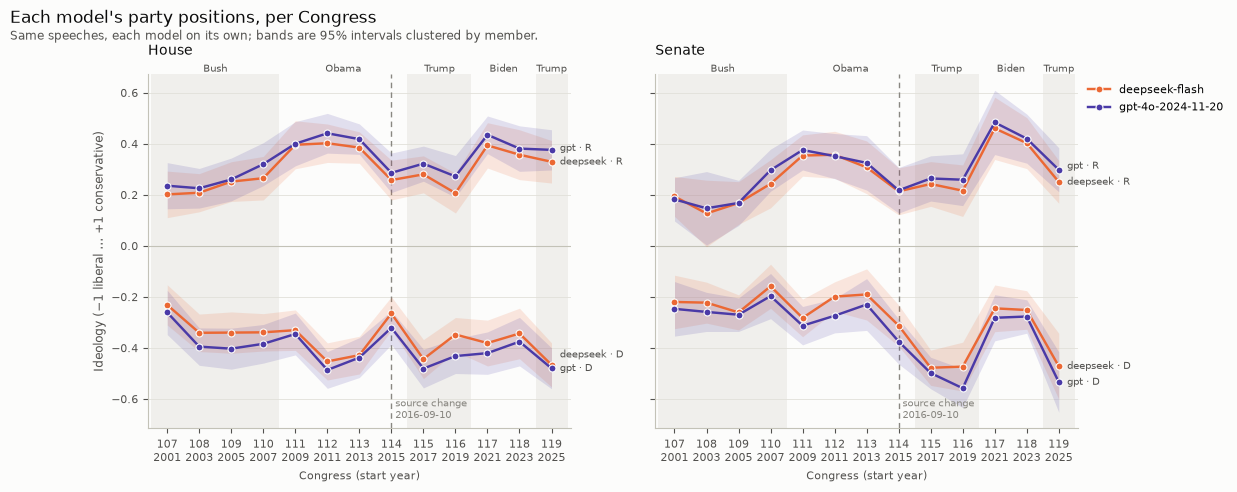

Trend 2001–2016 (Stanford only), per model:


,model,chamber,party,slope_ci,p
0,deepseek-flash,H,D,"-0.012 [-0.024, +0.000]",5.895e-02
1,deepseek-flash,H,R,"+0.022 [+0.010, +0.034]",3.653e-04
2,deepseek-flash,S,D,"-0.005 [-0.018, +0.008]",4.348e-01
3,deepseek-flash,S,R,"+0.020 [+0.003, +0.038]",2.500e-02
4,gpt-4o-2024-11-20,H,D,"-0.010 [-0.023, +0.003]",1.316e-01
5,gpt-4o-2024-11-20,H,R,"+0.023 [+0.011, +0.036]",2.728e-04
6,gpt-4o-2024-11-20,S,D,"-0.010 [-0.022, +0.002]",8.762e-02
7,gpt-4o-2024-11-20,S,R,"+0.021 [+0.002, +0.040]",2.773e-02


In [18]:
cells_by_model = {m: cell_means(df, value=f"ideology_{m}") for m in MODELS}
fig = plot_models(
    cells_by_model,
    "Each model's party positions, per Congress",
    subtitle="Same speeches, each model on its own; bands are 95% intervals clustered by member.",
)
save_figure(fig, "s8_model_comparison")
plt.show()

per_model = pd.concat([
    trend(df, value=f"ideology_{m}", congress_range=(107, 114)).assign(model=m) for m in MODELS
])
print("Trend 2001–2016 (Stanford only), per model:")
per_model.assign(slope_ci=with_ci(per_model, "slope", digits=3))[["model", "chamber", "party", "slope_ci", "p"]].reset_index(drop=True)

**The three-model evidence behind S15.** Pairwise agreement of all three models
on the 208 speeches of the stage-1 pilot (P6), where Claude Sonnet 4.6 still scored.

In [19]:
pilot = load_scored_run(PILOT_RUN)
pilot_models = run_models(SCORES_DIR, PILOT_RUN)
pilot[[f"ideology_{m}" for m in pilot_models]].rename(columns=lambda c: c.removeprefix("ideology_")).corr().round(3)

,deepseek-reasoner,gpt-4o-2024-11-20,claude-sonnet-4-6
deepseek-reasoner,1.000,0.952,0.952
gpt-4o-2024-11-20,0.952,1.000,0.969
claude-sonnet-4-6,0.952,0.969,1.000


**Reading it.** The two models agree at r = 0.94 (0.88 within Democrats, 0.91 within Republicans), and each on its own shows the same party lines and the same 2001–2016 trends: Republicans moving right in both chambers, Democrats not clearly. DeepSeek is slightly more moderate on both sides (+0.04 for Democrats, −0.03 for Republicans), and 4% of speeches differ by more than 0.42. In the pilot, GPT-4o and Sonnet agreed at 0.969, the closest of the three pairs — the basis for dropping Sonnet (S15).

## 9. Example speeches

What the scale means in practice: the most liberal and most conservative speeches
in the sample, and the speeches the two models disagree on most — with each
model's own one-line justification and the start of the speech.

In [20]:
def show(rows, title):
    texts = speech_texts(rows["speech_id"].tolist())
    print("=" * 100, "\n" + title, "\n" + "=" * 100)
    for _, r in rows.iterrows():
        print(f"\n{r['speech_id']} · {r['last_name'].title()} ({r['party']}-{r['state']}, "
              f"{'House' if r['chamber'] == 'H' else 'Senate'}) · {r['date']} · ensemble {r['ideology']:+.2f}")
        for m in MODELS:
            print(f"  {m}: ideology {r[f'ideology_{m}']:+.2f}, tone {r[f'tone_{m}']:.2f} — {r[f'reasoning_{m}']}")
        excerpt = textwrap.shorten(texts[r["speech_id"]], 700, placeholder=" …")
        print(textwrap.indent(textwrap.fill(excerpt, 98), "    "))

substantive = df[~df["procedural"]]
show(substantive.nsmallest(2, "ideology"), "Most liberal speeches")
show(substantive.nlargest(2, "ideology"), "Most conservative speeches")
show(disagreements(df, MODELS, top=3), "Largest disagreements between the models")

Most liberal speeches 

1100035230 · Maloney (D-NY, House) · 2007-04-19 · ensemble -1.00
  deepseek-flash: ideology -1.00, tone 0.95 — The speech strongly advocates abortion rights, criticizes the Supreme Court and Bush administration, and frames the issue in terms of women's human rights, placing it at the strongly liberal end of the spectrum.
  gpt-4o-2024-11-20: ideology -1.00, tone 0.90 — The speech strongly critiques a conservative court decision and supports reproductive rights, aligning with liberal policy positions such as defending a woman's right to choose.
    Madam Speaker. the Bush administration has gotten what they wished for. The Supreme Court has
    upheld a ban on a medical procedure for women without a health exception. thereby reversing four
    decades of rulings supporting a womansright to choose. Women who face serious health consequences
    have lost their right to the safest procedure available. Politicians have taken the place of
    doctors. @Printed on rec

Largest disagreements between the models 

gov-7cb7a7ab15d8dd97 · Merkley (D-OR, Senate) · 2023-11-14 · ensemble +0.05
  deepseek-flash: ideology +0.60, tone 0.95 — The speech is strongly internationalist and hawkish, advocating robust support for Ukraine, NATO, and U.S. leadership against Russia and other dictatorships; under the rubric, this aligns most closely with the 'strong national defense' conservative pole. It contains no clear domestic economic or social policy positions.
  gpt-4o-2024-11-20: ideology -0.50, tone 0.80 — The speech reflects a liberal-leaning ideology by emphasizing democratic values, international alliances, and opposition to authoritarian regimes, while criticizing appeasement and isolationism often associated with conservative arguments. It uses highly adversarial and partisan language, with repeated accusations and strong emotional appeals, resulting in a high tone score.
    Mr. President, reserving the right to object, our colleague from Kansas has come t

**Reading it.** The extremes are what one would expect: abortion rights and economic inequality at the liberal end, abortion restrictions and vaccine mandates at the conservative end. The disagreements show a real ambiguity in the construct rather than errors: DeepSeek tends to score the policy content against the rubric (support for Ukraine and NATO as "strong defense", opposition to tariffs as free trade — both conservative), while GPT-4o reads the partisan context (a Democrat attacking Republicans reads as liberal). The September pilot showed the same split (P2). Note also the OCR noise in Stanford texts ("womansright", "@Printed on recycledpaper"), which the models read through.

**Saving the tables.** The numbers behind the figures, to `results/metrics/`
(committed), so they can be quoted from a file rather than from notebook output.

In [21]:
tables = {
    "ideology_cells": cells,
    "party_gap": gaps,
    "ideology_trends": trends,
    "tone_cells": tone_cells,
    "tone_by_opposition": opposition,
    "member_validation": members,
}
for name, table in tables.items():
    path = METRICS_DIR / f"s8_{name}_{RUN}.csv"
    table.to_csv(path, index=False)
    print(path.relative_to(ROOT))

results/metrics/s8_ideology_cells_20261003T110419Z.csv
results/metrics/s8_party_gap_20261003T110419Z.csv
results/metrics/s8_ideology_trends_20261003T110419Z.csv
results/metrics/s8_tone_cells_20261003T110419Z.csv
results/metrics/s8_tone_by_opposition_20261003T110419Z.csv
results/metrics/s8_member_validation_20261003T110419Z.csv


## 10. Caveats and open questions

- **Preliminary.** These figures are for discussion in Meeting 2; none is final.
- **The 2016 source break.** govinfo yields ~20% fewer House and ~38% fewer Senate
  speeches per year than Stanford (O8). Movements that begin exactly at the 114th
  Congress — above all in the Senate — may partly reflect which speeches survive in
  each source. 2001–2016 is the clean window.
- **Equal quotas per cell.** Every Congress × party × chamber cell has 100 speeches,
  so a figure pooled across cells is not a corpus average.
- **Speeches, not members.** Each point is a mean over speeches; frequent speakers
  weigh more. Member-level averaging is explored in section 5 (O9 open).
- **Procedural speeches** (scored 0.0) are 34% of Republican and 28% of Democratic
  speeches; they pull means toward the centre. A robustness check without them is
  still to do.
- **Tone and ideology come from the same models reading the same text**, so their
  correlation may partly be the models conflating "strongly partisan" with
  "hostile" (section 6).
- **Trend and opposition cycle overlap** (section 7): with 13 Congresses, a
  long-run trend and the swing between government and opposition are hard to
  separate.
- **Two models, not three** (S15). The evidence that the third added little is the
  pilot correlation in section 8.
- **DeepSeek is DeepSeek-V4.1-Flash** (thinking mode), not R1 (M3b). 208 of its
  answers were carried over from the pilot under its former API name (S16); their
  length and agreement with GPT-4o match the new ones.
- **The 119th Congress covers 2025 only.**
- **Open:** which DW-NOMINATE score and unit validate the thesis (O9); whether to
  extend the sample (O11 — the per-cell intervals of roughly ±0.08 may already be
  enough for RQ1/RQ2).